In [2]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


In [3]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


Estimate MSM

In [4]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 250
Submodel for tica_distances has 50 microstates.
Submodel for pca_distances has 21 microstates.
Submodel for tica_dihedrals has 49 microstates.
Submodel for pca_dihedrals has 50 microstates.


Markov chain lag: 49.97 ns (250 frames)


'\n# Save figure\nfig.savefig(\n    "../output_figures/msm_timescale_spectra_report.png",\n    dpi=600,\n    bbox_inches="tight"\n)\nfig.savefig(\n    "../output_figures/msm_timescale_spectra_report.pdf",\n    bbox_inches="tight"\n)\nplt.show()\n'

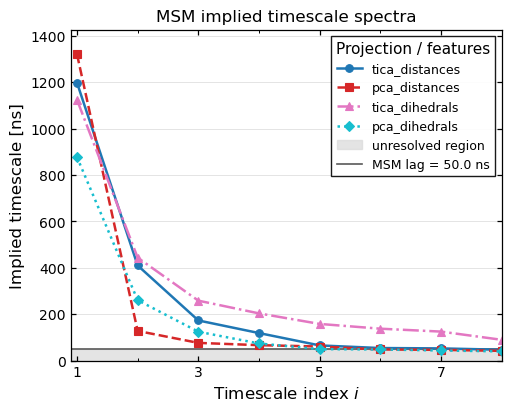

In [5]:
# ---------------------------------------------------------------------------
# Report-quality timescale spectrum plot: all MSMs in one panel

n_timescales = 8
msm_lag_ns = MSM_LAG_FRAMES * time_step_nanos
print(f"Markov chain lag: {msm_lag_ns:.2f} ns ({MSM_LAG_FRAMES} frames)")

# ---------------------------------------------------------------------------
# Figure

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    timescales_ns = np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos
    indices = np.arange(1, len(timescales_ns) + 1)


    ax.plot(
        indices,
        timescales_ns,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=rf"{name}"
    )

# ---------------------------------------------------------------------------
# MSM lag and threshold annotations

ax.axhspan(
    0,
    msm_lag_ns,
    color="0.85",
    alpha=0.7,
    zorder=0,
    label="unresolved region"
)

ax.axhline(
    msm_lag_ns,
    color="0.35",
    linestyle="-",
    linewidth=1.2,
    zorder=1,
    label=rf"MSM lag = {msm_lag_ns:.1f} ns"
)


# ---------------------------------------------------------------------------
# Axes formatting

ax.set_xlabel(r"Timescale index $i$")
ax.set_ylabel("Implied timescale [ns]")
ax.set_title("MSM implied timescale spectra")

ax.set_xlim(0.9, n_timescales)
ax.set_xticks(np.arange(1, n_timescales + 1, 2))
ax.set_xticks(np.arange(1, n_timescales + 1, 1), minor=True)

# Let the upper y-limit adapt to the data, threshold included
all_timescales = []

for name in trajectories_labels:
    msm = msm_dict[name]
    all_timescales.append(np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos)

all_timescales = np.concatenate(all_timescales)
finite_timescales = all_timescales[np.isfinite(all_timescales)]

ymax = max(
    np.nanmax(finite_timescales),
    #threshold_ns,
    msm_lag_ns
)

ax.set_ylim(0, 1.08 * ymax)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title="Projection / features",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)
# ---------------------------------------------------------------------------

"""
# Save figure
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.png",
    dpi=600,
    bbox_inches="tight"
)
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.pdf",
    bbox_inches="tight"
)
plt.show()
"""

Two state PCCA assignments

In [6]:
n_common = 2

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 2
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

In [7]:
import networkx as nx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def binned_probability_layout(
    G,
    x_values,
    n_bins=14,
    y_spacing=0.18,
):
    """
    Keep the physical x-coordinate while separating nearby nodes vertically.
    """
    x_values = np.asarray(x_values, dtype=float)

    # Ensure values exactly equal to 0 or 1 remain in valid bins
    bins = np.digitize(
        np.clip(x_values, 0, 1),
        np.linspace(0, 1, n_bins + 1),
        right=False,
    )
    bins = np.clip(bins, 1, n_bins)

    pos = {}

    for b in range(1, n_bins + 1):
        nodes = [node for node in G.nodes if bins[node] == b]

        if not nodes:
            continue

        # Put more populated nodes near the horizontal centre
        nodes = sorted(
            nodes,
            key=lambda node: G.nodes[node]["weight"],
            reverse=True,
        )

        offsets = np.arange(len(nodes), dtype=float)
        offsets -= offsets.mean()

        # Alternate above and below the centre
        order = np.argsort(np.abs(offsets))
        nodes = [nodes[i] for i in order]
        offsets = offsets[order]

        for node, y in zip(nodes, y_spacing * offsets):
            pos[node] = (x_values[node], y)

    return pos


def plot_msm_network_on_probability_axis(
    msm,
    x_values,
    title="MSM network projected on probability axis",
    min_flux=1e-5,
    top_k=5,
    min_node_size=80,
    max_node_size=1400,
    edge_scale=4.0,
    n_bins=14,
    y_spacing=0.18,
    connection_rad=0.12,
    label_population_threshold=0.05,
    cmap="viridis",
):
    P = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)
    x_values = np.asarray(x_values, dtype=float)

    n_states = P.shape[0]

    if P.shape != (n_states, n_states):
        raise ValueError("Transition matrix must be square.")

    if len(pi) != n_states:
        raise ValueError(
            "Stationary distribution must contain one value per state."
        )

    if len(x_values) != n_states:
        raise ValueError(
            "x_values must contain one value per MSM state."
        )

    # Equilibrium transition flux
    flux = pi[:, None] * P

    G = nx.DiGraph()

    for i in range(n_states):
        G.add_node(
            i,
            weight=pi[i],
            probability_coordinate=x_values[i],
        )

    # Retain the strongest outgoing non-self fluxes
    for i in range(n_states):
        candidate_states = np.argsort(flux[i])[::-1]

        kept = 0
        for j in candidate_states:
            if i == j:
                continue

            if flux[i, j] < min_flux:
                continue

            G.add_edge(
                i,
                j,
                weight=flux[i, j],
                probability=P[i, j],
            )

            kept += 1
            if kept >= top_k:
                break

    pos = binned_probability_layout(
        G,
        x_values,
        n_bins=n_bins,
        y_spacing=y_spacing,
    )

    # ------------------------------------------------------------
    # Node appearance
    # ------------------------------------------------------------

    # Square-root scaling compresses the population range.
    population_scaled = np.sqrt(pi / pi.max())

    node_sizes = (
        min_node_size
        + population_scaled * (max_node_size - min_node_size)
    )

    node_colors = x_values

    # ------------------------------------------------------------
    # Edge appearance
    # ------------------------------------------------------------

    edge_fluxes = np.array(
        [G[u][v]["weight"] for u, v in G.edges],
        dtype=float,
    )

    if len(edge_fluxes) > 0:
        positive_fluxes = edge_fluxes[edge_fluxes > 0]

        if len(positive_fluxes) > 0:
            reference_flux = np.percentile(positive_fluxes, 95)
            reference_flux = max(reference_flux, np.finfo(float).eps)

            # Square-root scaling prevents one edge from dominating.
            edge_widths = (
                0.25
                + edge_scale
                * np.sqrt(np.clip(edge_fluxes / reference_flux, 0, 1))
            )
        else:
            edge_widths = np.full(len(edge_fluxes), 0.5)
    else:
        edge_widths = []

    # Separate reciprocal edges by curving them in opposite directions
    positive_edges = []
    negative_edges = []
    straight_edges = []

    for u, v in G.edges:
        if G.has_edge(v, u):
            if u < v:
                positive_edges.append((u, v))
            else:
                negative_edges.append((u, v))
        else:
            straight_edges.append((u, v))

    edge_width_map = {
        edge: width
        for edge, width in zip(G.edges, edge_widths)
    }

    fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)

    def draw_edges(edge_list, radius):
        if not edge_list:
            return

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edge_list,
            width=[edge_width_map[e] for e in edge_list],
            edge_color="0.35",
            alpha=0.28,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=10,
            min_source_margin=5,
            min_target_margin=7,
            connectionstyle=f"arc3,rad={radius}",
            ax=ax,
        )

    draw_edges(straight_edges, 0.0)
    draw_edges(positive_edges, connection_rad)
    draw_edges(negative_edges, -connection_rad)

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=cmap,
        vmin=0,
        vmax=1,
        linewidths=0.8,
        edgecolors="white",
        alpha=0.95,
        ax=ax,
    )

    # Label only states with non-negligible equilibrium population.
    labels = {
        i: str(i)
        for i in G.nodes
        if pi[i] >= label_population_threshold
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=7,
        font_color="black",
        font_weight="medium",
        ax=ax,
    )

    # Probability-axis reference lines
    for x in np.linspace(0, 1, 6):
        ax.axvline(
            x,
            linewidth=0.6,
            color="0.88",
            linestyle="--",
            zorder=0,
        )

    ax.axhline(
        0,
        linewidth=0.7,
        color="0.82",
        zorder=0,
    )

    ax.set_xlim(-0.04, 1.04)

    y_values = np.array([y for _, y in pos.values()])
    if len(y_values):
        margin = max(0.25, 0.12 * np.ptp(y_values))
        ax.set_ylim(y_values.min() - margin, y_values.max() + margin)

    ax.set_xlabel("Probability coordinate", fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)

    # The vertical coordinate is only used for decluttering.
    ax.set_ylabel("")
    ax.set_yticks([])

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_color("0.35")

    ax.tick_params(axis="x", labelsize=9)
    ax.margins(x=0.02)

    colorbar = fig.colorbar(
        ScalarMappable(
            norm=Normalize(vmin=0, vmax=1),
            cmap=cmap,
        ),
        ax=ax,
        pad=0.02,
        fraction=0.035,
    )
    colorbar.set_label("Probability coordinate", fontsize=9)
    colorbar.ax.tick_params(labelsize=8)

    return fig, ax, G, pos

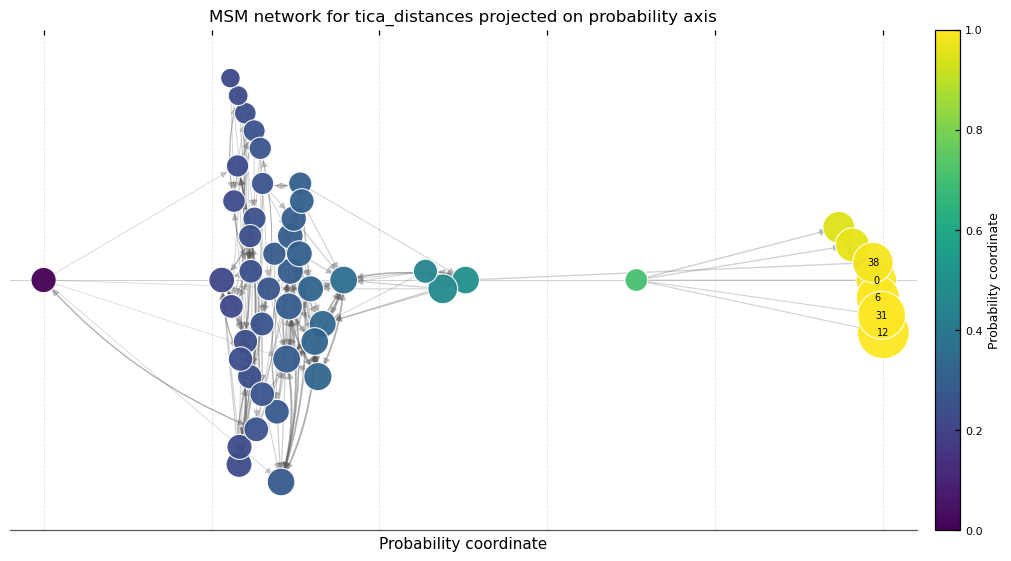

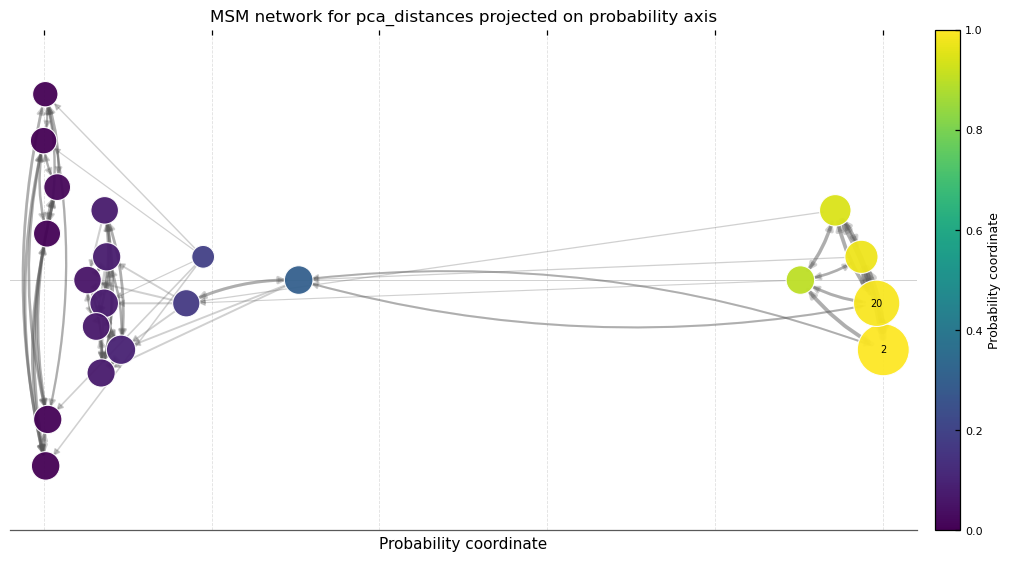

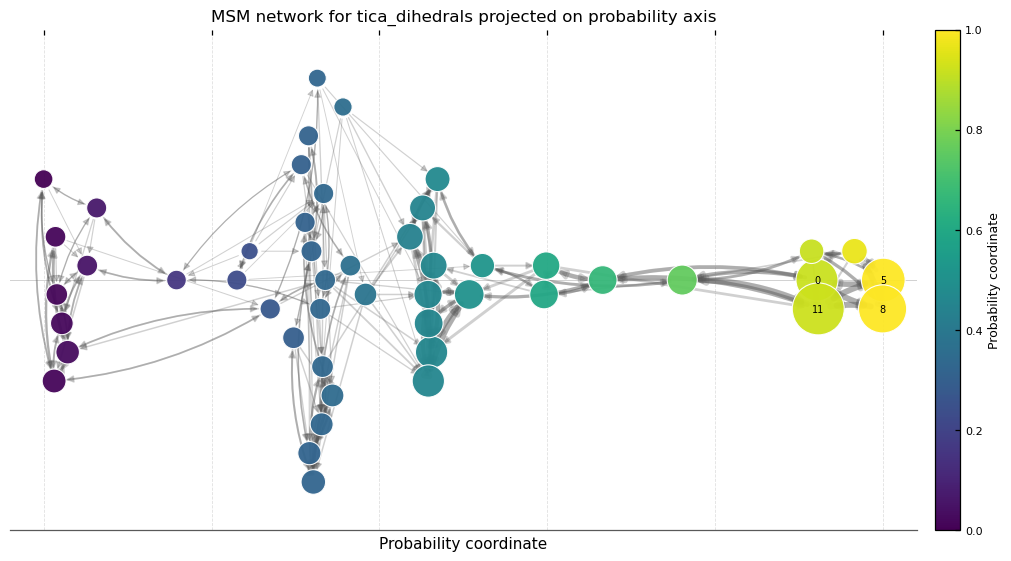

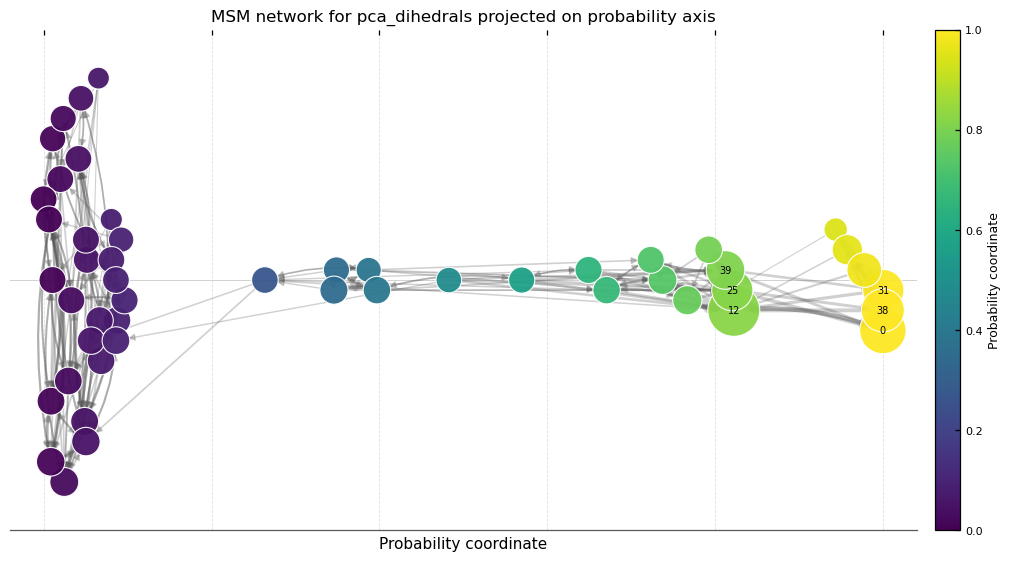

In [8]:
for traj in trajectories_labels:
    msm = msm_dict[traj]
    p_macro1_per_state = pcca_dict[traj].memberships[:, 1]

    fig, ax, G, pos = plot_msm_network_on_probability_axis(
        msm,
        x_values=p_macro1_per_state,
        min_flux=1e-5
    )

    ax.set_title(f"MSM network for {traj} projected on probability axis")
    plt.show()

---

# Dihedrals - more in depth
Lets check the two variations of the folded basin as found by the dihedrals representation

In [23]:
name = "tica_dihedrals"
state_partitions = [[0, 11], [5, 8]]  


dtraj = micro_trajectory_dict[name]


# Masks
state_masks = [np.isin(dtraj, state_partitions[0]), np.isin(dtraj, state_partitions[1])]

state_populations = [np.sum(mask) for mask in state_masks]
print(f"State masks for {name}: ")
for i, (mask, pop) in enumerate(zip(state_masks, state_populations)):
    print(f"  State {state_partitions[i]}: {pop} frames, {pop / len(dtraj) * 100:.2f}% of total")



first_state_mask = state_masks[0]
second_state_mask = state_masks[1]

State masks for tica_dihedrals: 
  State [0, 11]: 529405 frames, 34.69% of total
  State [5, 8]: 451262 frames, 29.57% of total


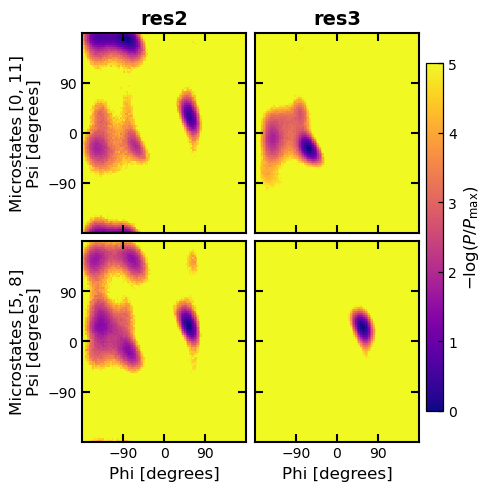

In [22]:


from matplotlib.colors import Normalize

# -----------------------------
# Load dihedrals
# -----------------------------
dihedral_timeseries = np.loadtxt(
    data_folder + "hp35.dihs",
    delimiter=" ",
    dtype=float
)

phis_timeseries = dihedral_timeseries[:, 0::2]   # degrees
psis_timeseries = dihedral_timeseries[:, 1::2]   # degrees




residues_to_plot = [2, 3]  # Residues 2 to 33
residue_names = [f"res{r}" for r in residues_to_plot]
residue_cols = [r - 2 for r in residues_to_plot]




# -----------------------------
# Define macrostate masks
# -----------------------------
# Option A: if you already have frame arrays
macrostate_frames = {
   f"Microstates [{', '.join(map(str, state_partitions[0]))}]": first_state_mask,
   f"Microstates [{', '.join(map(str, state_partitions[1]))}]": second_state_mask,
}



# -----------------------------
# Ramachandran free-energy helper
# -----------------------------
def ramachandran_free_energy(phi, psi, bins=100, pseudocount=1e-12):
    """
    Returns bin centers and F = -log(P / Pmax).
    Low F = highly populated.
    """
    H, phi_edges, psi_edges = np.histogram2d(
        phi,
        psi,
        bins=bins,
        range=[[-180, 180], [-180, 180]],
        density=False
    )

    P = H / np.sum(H)
    P = P + pseudocount

    F = -np.log(P / np.max(P))
    F = F.T   # transpose for plotting: y=psi, x=phi

    phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    psi_centers = 0.5 * (psi_edges[:-1] + psi_edges[1:])

    return phi_centers, psi_centers, F


# -----------------------------
# Plot
# -----------------------------
n_rows = len(macrostate_frames)
n_cols = len(residue_cols)

fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.4 * n_cols, 2.4 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

vmax = 5.0
norm = Normalize(vmin=0, vmax=vmax)

last_im = None

for row, (macro_name, frames) in enumerate(macrostate_frames.items()):

    for col, (res_name, res_col) in enumerate(zip(residue_names, residue_cols)):

        ax = axs[row, col]

        phi = phis_timeseries[frames, res_col]
        psi = psis_timeseries[frames, res_col]

        x, y, F = ramachandran_free_energy(phi, psi, bins=100)

        F_plot = np.clip(F, 0, vmax)

        last_im = ax.pcolormesh(
            x,
            y,
            F_plot,
            shading="auto",
            cmap="plasma",
            norm=norm
        )

        # titles only on top row
        if row == 0:
            ax.set_title(res_name, fontsize=14, fontweight="bold")

        # macrostate labels only on left
        if col == 0:
            ax.set_ylabel(f"{macro_name}\nPsi [degrees]", fontsize=12)

        # x labels only on bottom row
        if row == n_rows - 1:
            ax.set_xlabel("Phi [degrees]", fontsize=12)

        ax.set_xlim(-180, 180)
        ax.set_ylim(-180, 180)

        ax.set_xticks([-90, 0, 90])
        ax.set_yticks([-90, 0, 90])

        ax.tick_params(
            direction="in",
            length=6,
            width=1.5,
            top=True,
            right=True
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)


# Shared colorbar
cbar = fig.colorbar(
    last_im,
    ax=axs,
    location="right",
    shrink=0.85,
    pad=0.02
)
cbar.set_label(r"$-\log(P/P_{\max})$", fontsize=12)
cbar.set_ticks([0, 1, 2, 3, 4, 5])

plt.show()